In [27]:
# Базовые библиотеки
import numpy as np
import pandas as pd

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Разделение данных
from sklearn.model_selection import train_test_split

# Предобработка
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Yellowbrick
from yellowbrick.features import Rank2D
from yellowbrick.features import RadViz
from yellowbrick.features import ParallelCoordinates
from yellowbrick.target import FeatureCorrelation

# Настройки отображения
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

# Блок 0. Создание искусственных данных для тестирования пайплайна


In [28]:


def create_raw_test_data(
    n_samples: int = 5000,
    n_locations: int = 3,
    n_days: int = 30,
    random_seed: int = 42
) -> pd.DataFrame:
    """
    Создает МИНИМАЛЬНЫЙ сырой датафрейм для тестирования пайплайна.
    БЕЗ feature engineering — только то, что приходит из источника.
    """
    np.random.seed(random_seed)
    
    start_date = pd.to_datetime("2024-01-01")
    timestamps = pd.date_range(start=start_date, periods=n_days * 24, freq='h')
    
    data = []
    
    for loc_id in range(n_locations):
        # Простые координаты
        lat = 55.0 + np.random.rand() * 10
        lon = 30.0 + np.random.rand() * 20
        
        for ts in timestamps:
            # Сырая температура (только шум + суточный цикл)
            temperature = 10 + 5 * np.sin(2 * np.pi * ts.hour / 24) + np.random.normal(0, 3)
            
            # Сырые осадки
            precipitation = np.random.exponential(1) if np.random.random() < 0.2 else 0
            
            # Целевая переменная (зависит от температуры, чтобы была корреляция)
            target = 50 + temperature * 2 + np.random.normal(0, 5)
            
            data.append({
                "location_id": loc_id,
                "lat": lat,
                "lon": lon,
                "date": ts,
                "temperature": round(temperature, 1),
                "precipitation": round(precipitation, 2),
                "target": round(target, 2)
            })
    
    df = pd.DataFrame(data)
    
    # Добавляем пропуски в случайные столбцы
    for col in ["temperature", "precipitation"]:
        mask = np.random.random(len(df)) < 0.03
        df.loc[mask, col] = np.nan
    
    print(f"✅ Создан сырой датафрейм для тестирования EDA:")
    print(f"   - Всего записей: {len(df)}")
    print(f"   - Столбцы: {list(df.columns)}")
    print(f"   - Пропусков: {df.isnull().sum().sum()}")
    
    return df

# Создаём
df = create_raw_test_data(n_samples=5000, n_locations=3, n_days=14)

print("\nПервые 5 строк:")
display(df.head())

print("\nИнформация:")
df.info()

✅ Создан сырой датафрейм для тестирования EDA:
   - Всего записей: 1008
   - Столбцы: ['location_id', 'lat', 'lon', 'date', 'temperature', 'precipitation', 'target']
   - Пропусков: 49

Первые 5 строк:


,location_id,lat,lon,date,temperature,precipitation,target
0,0,58.745401,49.014286,2024-01-01 00:00:00,11.9,0.17,81.50
1,0,58.745401,49.014286,2024-01-01 01:00:00,16.0,3.50,85.90
2,0,58.745401,49.014286,2024-01-01 02:00:00,11.1,0.20,74.90
3,0,58.745401,49.014286,2024-01-01 03:00:00,14.3,0.00,68.96
4,0,58.745401,49.014286,2024-01-01 04:00:00,16.8,0.35,75.94



Информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   location_id    1008 non-null   int64         
 1   lat            1008 non-null   float64       
 2   lon            1008 non-null   float64       
 3   date           1008 non-null   datetime64[ns]
 4   temperature    979 non-null    float64       
 5   precipitation  988 non-null    float64       
 6   target         1008 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 55.2 KB


## Далее - предполагаем, что имеем df

In [29]:
# Типы столбцов
display(df.dtypes)

# Пропуски
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

# Дубли
print("Количество полных дублей:", df.duplicated().sum())

location_id               int64
lat                     float64
lon                     float64
date             datetime64[ns]
temperature             float64
precipitation           float64
target                  float64
dtype: object

temperature      29
precipitation    20
dtype: int64

Количество полных дублей: 0


### EDA 

In [30]:
# Типы столбцов
display(df.dtypes)


location_id               int64
lat                     float64
lon                     float64
date             datetime64[ns]
temperature             float64
precipitation           float64
target                  float64
dtype: object

In [31]:
# Пропуски
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])


temperature      29
precipitation    20
dtype: int64

In [32]:
# Дубли
print("Количество полных дублей:", df.duplicated().sum())

Количество полных дублей: 0


In [33]:
# Удаляем дубликаты (если есть)
dup_mask = df.duplicated()
if dup_mask.sum() > 0:
    df = df[~dup_mask].reset_index(drop=True)
    print(f"✅ Удалено дубликатов: {dup_mask.sum()}")
else:
    print("Дубликатов не найдено.")

Дубликатов не найдено.


In [34]:
# Проверяем пропуски после удаления дубликатов
missing_after = df.isna().sum().sort_values(ascending=False)
display(missing_after[missing_after > 0])

temperature      29
precipitation    20
dtype: int64

In [35]:
# Удаляем столбцы с >70% пропусков (если такие есть)
high_missing_threshold = 70
missing_pct = df.isna().mean() * 100
high_missing_cols = missing_pct[missing_pct > high_missing_threshold].index.tolist()

if high_missing_cols:
    df = df.drop(columns=high_missing_cols)
    print(f"Удалены столбцы с >{high_missing_threshold}% пропусков: {high_missing_cols}")
else:
    print(f"Нет столбцов с >{high_missing_threshold}% пропусков.")

Нет столбцов с >70% пропусков.


### Обновить списки признаков после удаления

In [36]:
# Описательная статистика для числовых колонок
num_cols_before = df.select_dtypes(include=[np.number]).columns.tolist()
print("Числовые столбцы до очистки:", num_cols_before)

Числовые столбцы до очистки: ['location_id', 'lat', 'lon', 'temperature', 'precipitation', 'target']


In [37]:

display(df[num_cols_before].describe().T)

,count,mean,std,min,25%,50%,75%,max
location_id,1008.0,1.000000,0.816902,0.00000,0.00000,1.000000,2.000000,2.000000
lat,1008.0,58.676522,1.254918,57.10705,57.10705,58.745401,60.177116,60.177116
lon,1008.0,43.306859,8.170989,31.75733,31.75733,49.014286,49.148960,49.148960
temperature,979.0,9.864964,4.593343,-3.40000,6.60000,9.900000,13.200000,22.700000
precipitation,988.0,0.229889,0.684512,0.00000,0.00000,0.000000,0.000000,6.810000
target,1008.0,69.928264,10.299573,42.31000,62.42500,70.110000,77.130000,102.210000


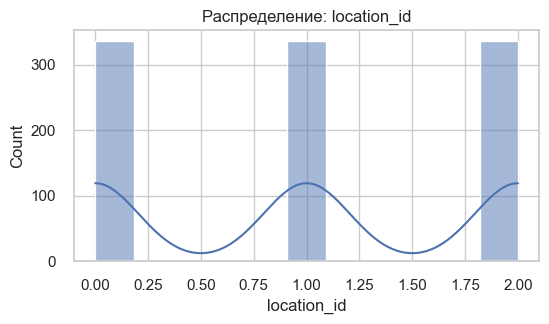

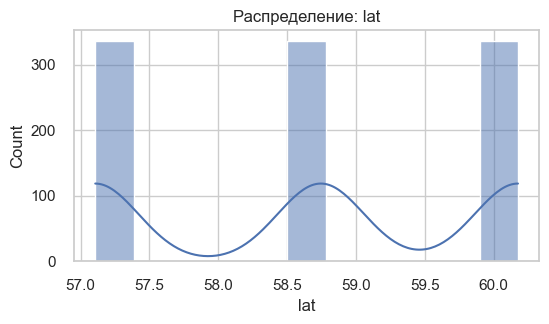

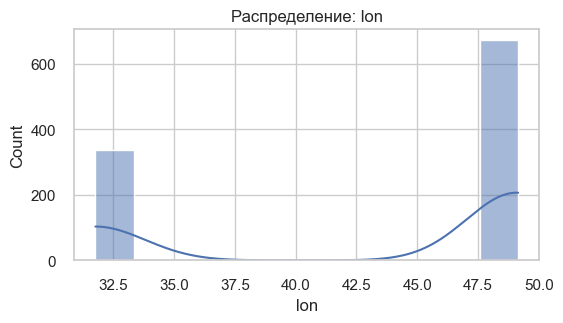

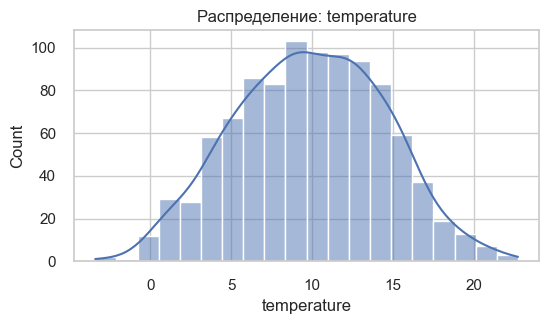

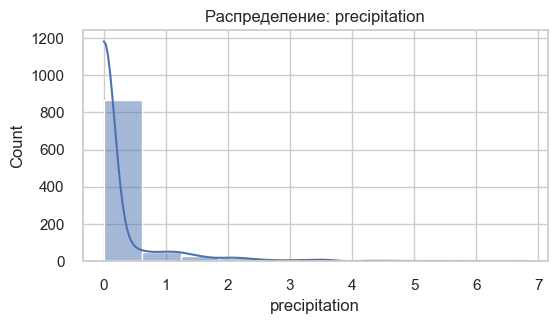

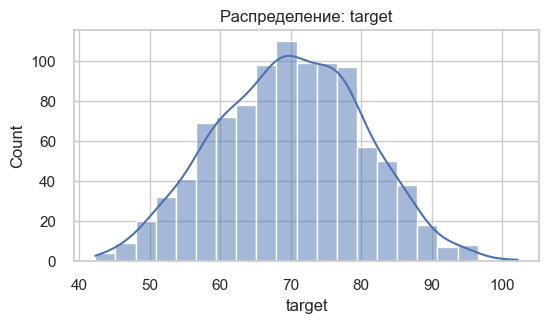

In [38]:
# Визуализация распределений числовых признаков
sample_num_cols = num_cols_before[:6]  # ограничим для наглядности

for col in sample_num_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Распределение: {col}")
    plt.show()

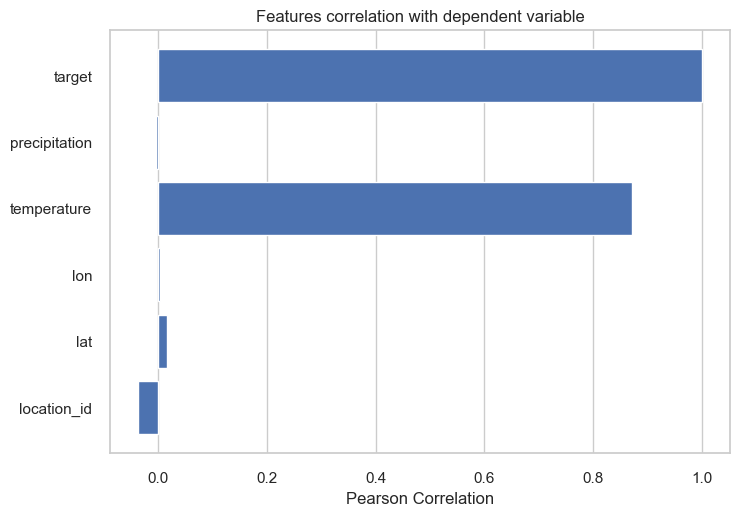

In [39]:
# Связь признаков с target
if len(num_cols_before) > 0:
    fc = FeatureCorrelation(labels=num_cols_before)
    fc.fit(df[num_cols_before].fillna(df[num_cols_before].median()), df["target"])
    fc.show()

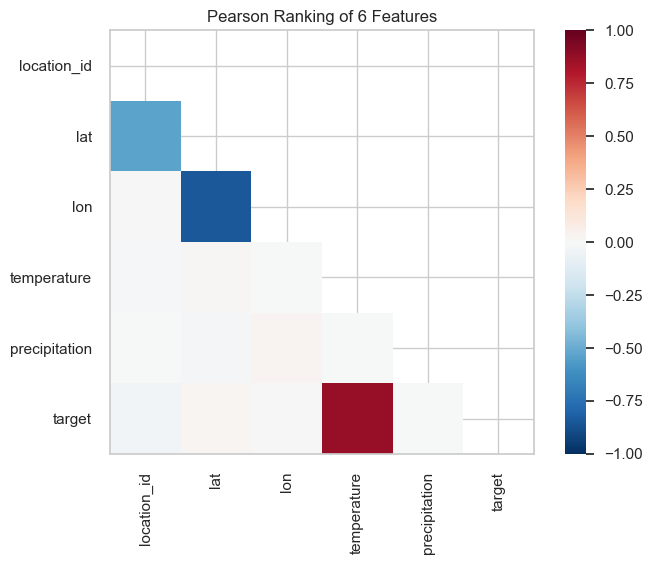

In [40]:
# Корреляции
# Только если есть хотя бы 2 числовых признака
if len(num_cols_before) >= 2:
    visualizer = Rank2D(features=num_cols_before, algorithm="pearson")
    visualizer.fit(df[num_cols_before].fillna(df[num_cols_before].median()))
    visualizer.transform(df[num_cols_before].fillna(df[num_cols_before].median()))
    visualizer.show()

Проверка выбросов

In [42]:
# Функция для обработки выбросов
def clip_outliers_iqr(df_num: pd.DataFrame):
    """
    Ограничивает выбросы по IQR.
    Возвращает новый датафрейм с обработанными значениями и словарь границ.
    """
    df_num_clipped = df_num.copy()
    bounds = {}

    for col in df_num.columns:
        s = df_num[col].dropna()
        if len(s) == 0:
            continue

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        bounds[col] = (lower, upper)

        df_num_clipped[col] = df_num[col].clip(lower, upper)

    return df_num_clipped, bounds

Применение мягкой обработки выбросов

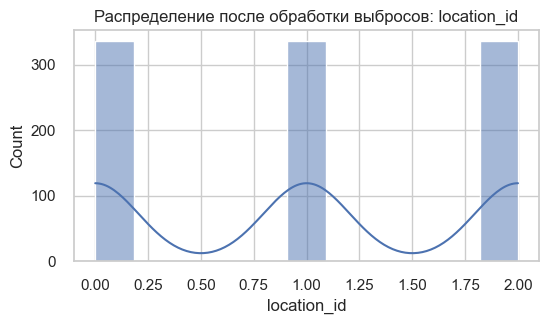

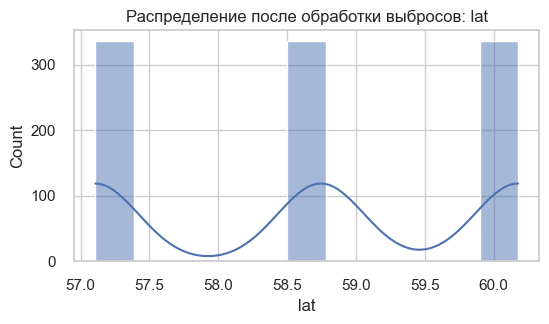

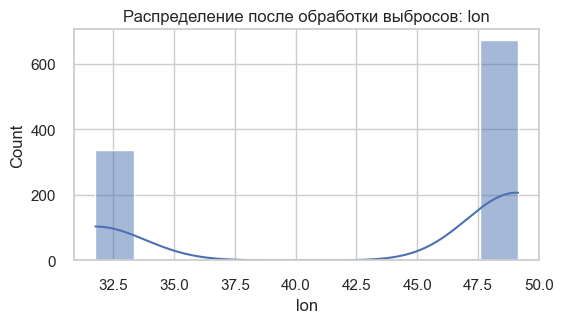

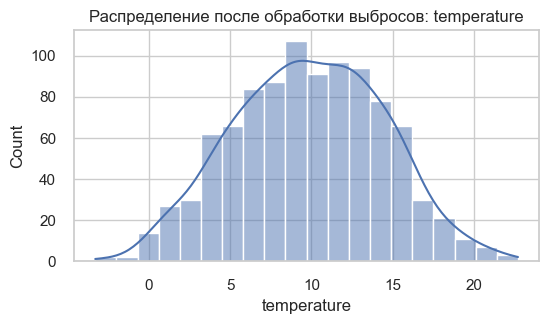

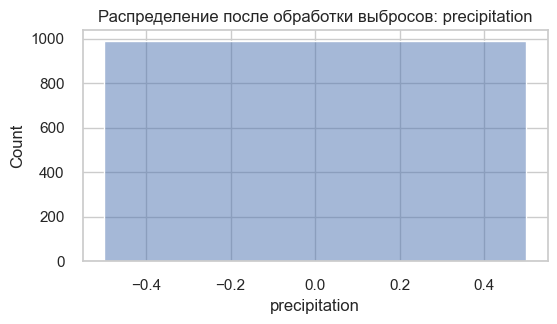

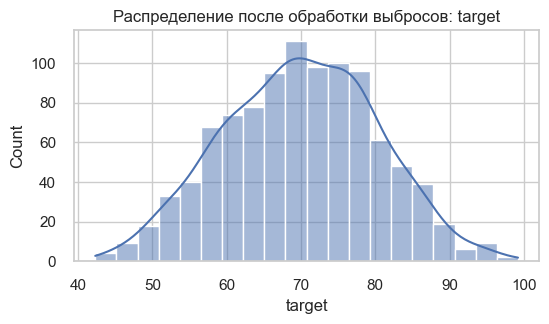

In [43]:
# Применяем обработку выбросов к числовым колонкам
df_num = df[num_cols_before].copy()
df_num_clipped, outlier_bounds = clip_outliers_iqr(df_num)

# Обновляем исходный датафрейм
df[num_cols_before] = df_num_clipped

# Проверяем распределение после обработки
for col in sample_num_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Распределение после обработки выбросов: {col}")
    plt.show()

In [44]:
# Итоговый "чистый" датафрейм для дальнейшего feature engineering
df_clean = df.copy()

print("✅ Итоговый очищенный датафрейм:")
print(f"   - Форма: {df_clean.shape}")
print(f"   - Столбцы: {list(df_clean.columns)}")
print(f"   - Пропусков: {df_clean.isnull().sum().sum()}")
print("\nПервые 5 строк:")
display(df_clean.head())

✅ Итоговый очищенный датафрейм:
   - Форма: (1008, 7)
   - Столбцы: ['location_id', 'lat', 'lon', 'date', 'temperature', 'precipitation', 'target']
   - Пропусков: 49

Первые 5 строк:


,location_id,lat,lon,date,temperature,precipitation,target
0,0,58.745401,49.014286,2024-01-01 00:00:00,11.9,0.0,81.50
1,0,58.745401,49.014286,2024-01-01 01:00:00,16.0,0.0,85.90
2,0,58.745401,49.014286,2024-01-01 02:00:00,11.1,0.0,74.90
3,0,58.745401,49.014286,2024-01-01 03:00:00,14.3,0.0,68.96
4,0,58.745401,49.014286,2024-01-01 04:00:00,16.8,0.0,75.94


## Экспорт ноутбука в HTML
- Если хотите разместить его на своём сайте
```bash
jupyter nbconvert --to html notebooks/01_baseline_tabular.ipynb
```